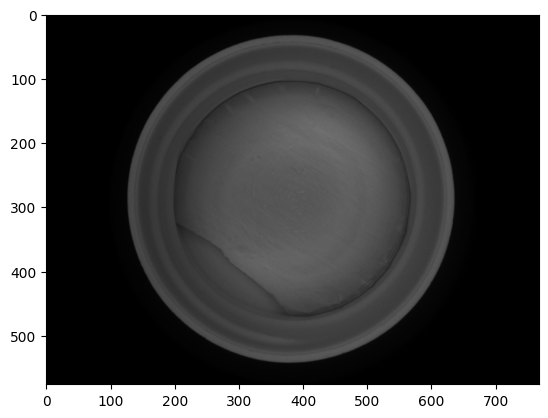

CAP OUTLINE - center: x=  381.5  y=  285.5  , radius=  253.8


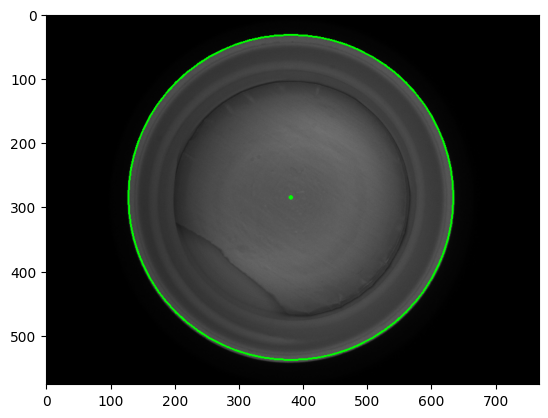

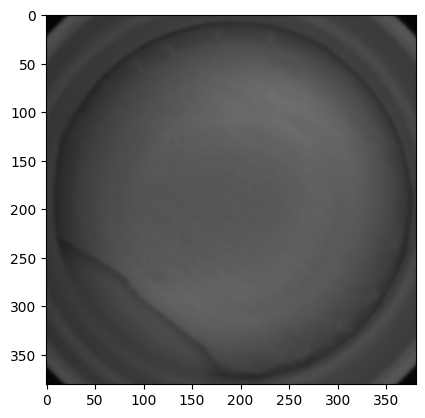

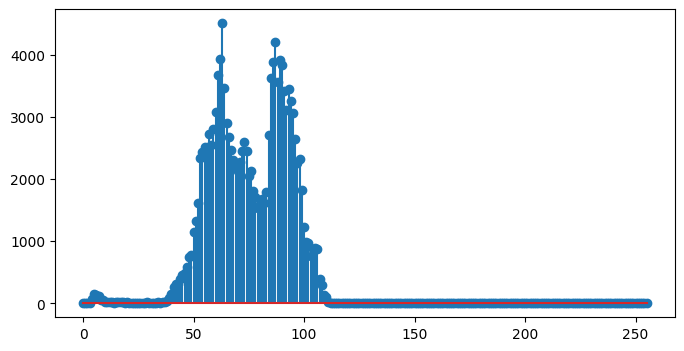

75.52706305412612
liner


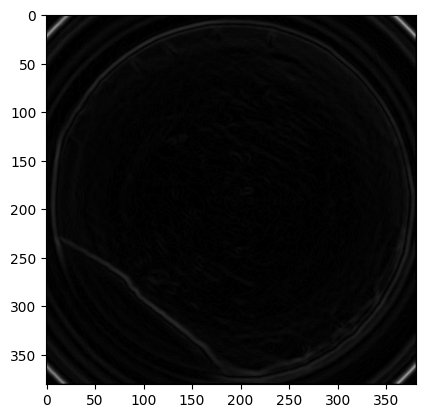

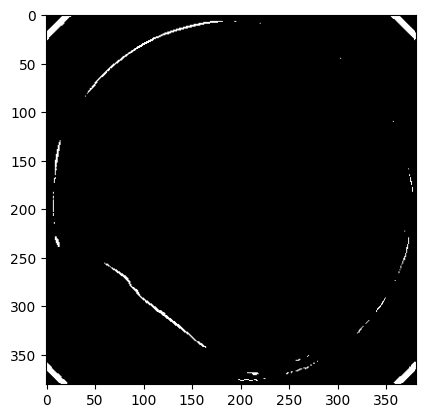

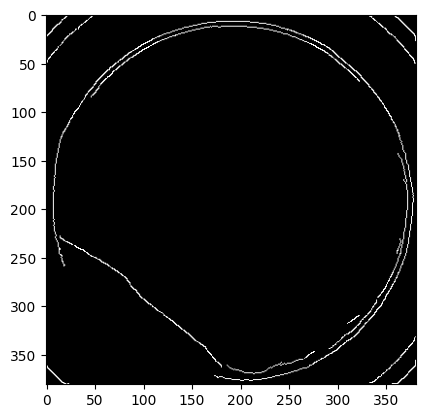

canny-LINE: ( -103.208534 , 127.45195 ) - theta=  2.2514746  - rho:  164.0
canny-LINE: ( -104.04679 , 133.17383 ) - theta=  2.2340214  - rho:  169.0
sobel-LINE: ( -104.04679 , 133.17383 ) - theta=  2.2340214  - rho:  169.0
sobel-LINE: ( -103.208534 , 127.45195 ) - theta=  2.2514746  - rho:  164.0
sobel-LINE: ( -100.37702 , 115.47058 ) - theta=  2.2863812  - rho:  153.0
sobel-LINE: ( -105.31764 , 139.7612 ) - theta=  2.2165682  - rho:  175.0
sobel-LINE: ( -102.20323 , 121.80106 ) - theta=  2.268928  - rho:  159.0


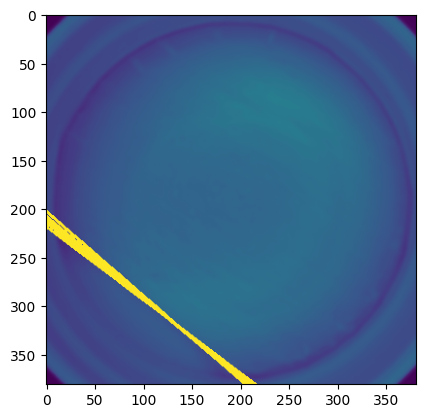

LINER - center (in roi pic): x=  191.5  y=  193.5  - center (in full pic): x=  382.5  y=  288.5  , radius=  185.2


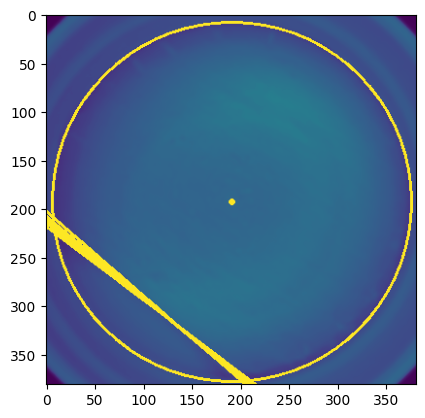

In [2]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

#### LOAD and show IMAGE
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_19.bmp')
#img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/g_06.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.show()

#### histogram 
hist, bins = np.histogram(img.flatten(), 256, [0,256])
'''
plt.figure(2,figsize=[8,4])
plt.stem(hist)
plt.show()
'''
######## TASK 1.1:  Outline the cap by generating a circle that fits the cap mouth #########
#img_blur = cv2.GaussianBlur(img,(7,7),0)
img_blur = cv2.bilateralFilter(img,7,50,75)
circles = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 45,param1=70,param2=70) # ok per trovare esterno dei tappi
# param1: threshold della differenza del gradiente (+alto = colori + diversi) (per il canny "integrato") - + alta mi trova solo il cerchio esterno
# param2 : perfezione del cerchio
#print(circles, circles.shape)
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]
'''for c in circles[0,:] : 
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])
'''

cv2.circle(img_color,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(img_color,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )
plt.imshow(img_color)
plt.show()

#### ROI OF INSIDE THE CAP
offset = ((radius/math.sqrt(2))+radius)/2 # half way
offset = (radius/math.sqrt(2)) # inscritta
offset = (radius*0.8) # accazzodicane ma funziona
offset = (radius*0.75) # accazzodicane ma funziona
x_max=math.ceil(center[0]+offset)
x_min=math.floor(center[0]-offset)
y_max=math.ceil(center[1]+offset)
y_min=math.floor(center[1]-offset)  



img_roi=img_blur[y_min:y_max,x_min:x_max]
img_roi_show=img_roi.copy()
plt.figure()
plt.imshow(img_roi,cmap='gray',vmin=0,vmax=255)
plt.show()
hist_roi, bins_roi = np.histogram(img_roi.flatten(), 256, [0,256])

plt.figure(2,figsize=[8,4])
plt.stem(hist_roi)
plt.show()


###########################LINER O NO LINER CON AVERAGE LIGHTNESS
avg=cv2.mean(img_roi)[0]
print(avg)              ########## LINER: intorno a 70 - NO LINER: intorno a 90 - "threshold"=80 
if avg>80 : 
    print("NO LINER")
else :     
    ############################TROVARE IL DIFETTO "INSPECTING THE MAGNITUDE OF THE GADIENT"
    print("liner")
    img_roi_sobelx = cv2.Sobel(img_roi,cv2.CV_64F,1,0,ksize=3)
    img_roi_sobely = cv2.Sobel(img_roi,cv2.CV_64F,0,1,ksize=3)
    img_roi_gradient_magnitude = cv2.convertScaleAbs(cv2.magnitude(img_roi_sobelx, img_roi_sobely))
    plt.figure()
    plt.imshow(img_roi_gradient_magnitude,cmap='gray',vmin=0,vmax=255)
    plt.show()

    #keep only strong edges
    th , edges = cv2.threshold(img_roi_gradient_magnitude, 30, 255, cv2.THRESH_BINARY)
    plt.figure()
    plt.imshow(edges,cmap='gray',vmin=0,vmax=255)
    plt.show()
    
    edges_c = cv2.Canny(img_roi,15,30,apertureSize=3)
    plt.figure()
    plt.imshow(edges_c,cmap='gray',vmin=0,vmax=255)
    plt.show()

    
     ###con houghlines e basta sobel trova più linee anche "spurie" wrt i nostri interessi
    lines = cv2.HoughLines(edges_c,1,np.pi/180,70)
    if lines is not None and len(lines) > 0:
        #
        
        for line in lines:
            rho, theta = line[0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho    
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            print("canny-LINE: (",x0,",",y0,") - theta= ",theta," - rho: ",rho)
            cv2.line(img_roi_show, (x1, y1), (x2, y2), (0, 0, 255), 2)

    
    lines = cv2.HoughLines(edges,1,np.pi/180,70)
    if lines is not None and len(lines) > 0:
        #
        
        for line in lines:
            rho, theta = line[0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho    
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            print("sobel-LINE: (",x0,",",y0,") - theta= ",theta," - rho: ",rho)
            cv2.line(img_roi_show, (x1, y1), (x2, y2), (255, 0, 255), 2)
                  
    plt.imshow(img_roi_show)
    plt.show()    
    
        
circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 50,param1=40,param2=60) # d_18 ne trova 3 ma il primo è quello giusto
#circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 45,param1=40,param2=60) # ALL OK EXCEPT G_04 if keep "half way" ROI
#cerchiamo il cerchio interno nella roi e poi per visualizzarlo gli diamo l'offset per ritrovarlo nell'immagine grande ((0,0) in img_roi = (x_min,y_min) in img "full")
# !!!!!!!!!!!11 d_31 questa non la trova (che ci sta che sia così)
if circles_in is not None and len(circles_in) > 0:

    #print(circles, circles.shape)
    for c in circles_in[0,:] : 
        cv2.circle(img_roi_show,(int(c[0]),int(c[1])),int(c[2]),color=(255, 0, 0),thickness=2)
        cv2.circle(img_roi_show,(int(c[0]),int(c[1])),int(2),color=(255,0, 0),thickness=2)
        print("LINER - center (in roi pic): x= ", c[0]," y= ",c[1]," - center (in full pic): x= ", c[0]+x_min," y= ",c[1]+y_min," , radius= ",c[2])

    plt.figure()
    
    plt.imshow(img_roi_show)
    plt.show()
else : 
    print("NO LINER")



################################ CI PIACE DI PUÙ CANNY CHE SOBEL TANTO ALLA FINE ANCHE CANNY DENTRO VA A CALCOLARSI IL GRADIENTE
################################## VA BENE AS IS 
################################# AGGIUNGERE ALTERNATIVA PER NO LINER/LINER CON AVG LIGHTNESS
